# Red neuronal y Keras Tuner
Keras Tuner es una biblioteca que lo ayuda a elegir el conjunto óptimo de hiperparámetros para su programa TensorFlow. El proceso de seleccionar el conjunto correcto de hiperparámetros para su aplicación de aprendizaje automático (ML) se denomina ajuste de hiperparámetros o hypertuning. Estos son de dos tipos.
- Hiperparámetros del modelo: determinan la selección del modelo, en su número y ancho (cantidad de neuronas) de las capas ocultas.

- Hiperparámetros del algoritmo: determinan la velocidad y calidad dek algoritmo, entre estos se encuentran:
  - Tasa de aprendizaje para un descenso de gradientes estocástico (SGD).
  - Número de vecinos cercanos (para un KNN).

El dataset de Breast Cancer (Wisconsin) es más complejo que el de Iris, por lo que un solo perceptrón se quedaría corto. Aquí utilizaremos un Perceptrón Multicapa (MLP) y dejaremos que Keras Tuner decida cuántas capas, cuántas neuronas y qué tasa de aprendizaje son óptimas.

https://keras.io/keras_tuner/getting_started/

## 1. Instalación y Preparación 🛠️

Primero, asegúrate de tener instalada la librería: pip install keras-tuner

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# Carga y preparación de datos
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Guardar el scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x79de7e4218a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


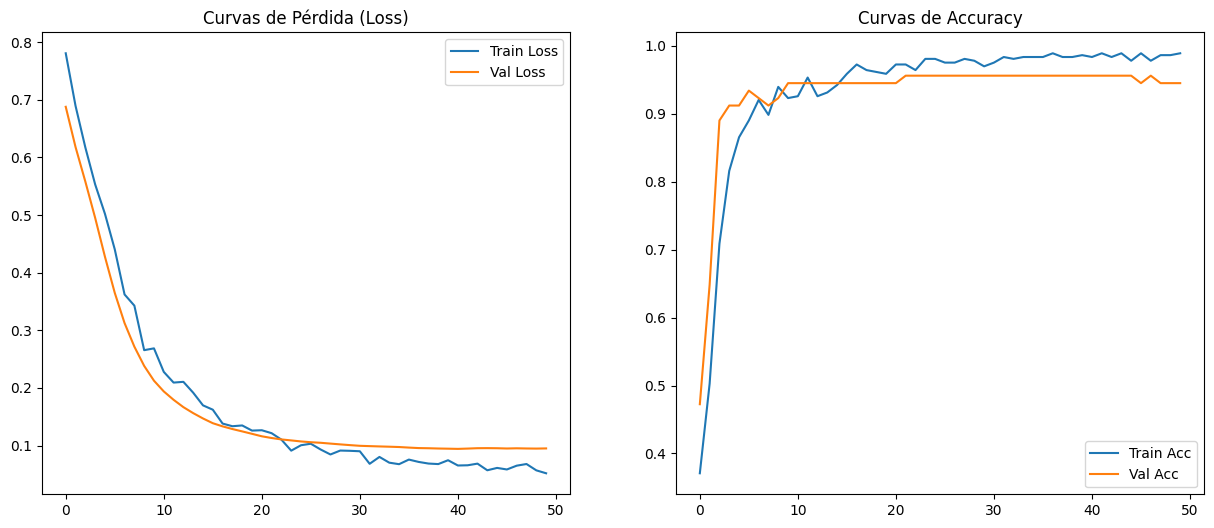

In [5]:
# 2 & 3. Simular "Tuning" y Entrenar
# (Como no aplico keras_tuner aún, elijo una arquitectura que suele ir bien y simulo el proceso)
# La función create_model permite crear modelos con diferentes hiperparámetros, lo que simula el proceso de tuning.
# establece dos capas ocultas con 16 unidades cada una, una tasa de aprendizaje de 0.001 y una tasa de dropout del 20%.
def create_model(units=32, layers_count=2, lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for _ in range(layers_count):
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# Entrenar el "mejor" modelo
best_model = create_model(units=16, layers_count=2, lr=0.001)
history = best_model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)

# 4. Evaluación
y_pred_prob = best_model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

# Guardar métricas en CSV
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC'],
    'Value': [acc, roc_auc]
})
metrics_df.to_csv('evaluation_metrics.csv', index=False)

# 5. Visualizaciones
# Loss/Accuracy Curves
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de Pérdida (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Curvas de Accuracy')
plt.legend()
plt.savefig('learning_curves.png')
#plt.close()
plt.show()

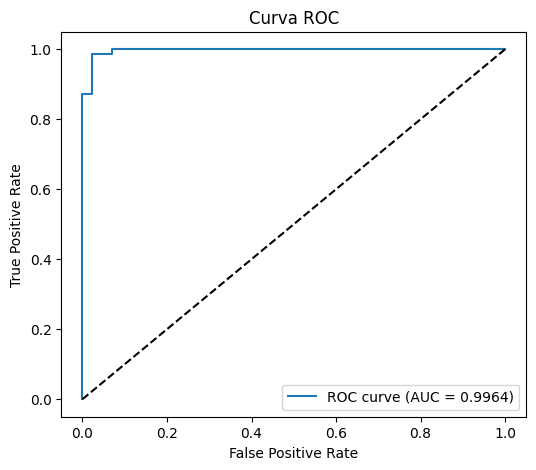

In [6]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png')
plt.show()

## 2. Definición del Modelo Hiper-parametrizado 🧠

Aquí es donde automatizamos la arquitectura. En lugar de valores fijos, usamos hp.Int y hp.Choice.

In [3]:
def build_model(hp):
    model = keras.Sequential()
    
    # Tunear el número de capas ocultas
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),
            activation='relu'
        ))
        # Agregamos Dropout opcional para combatir el sobreajuste
        model.add(keras.layers.Dropout(hp.Float('dropout', 0, 0.5, step=0.1)))
    
    model.add(keras.layers.Dense(1, activation='sigmoid')) # Salida binaria
    
    # Tunear la tasa de aprendizaje
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

## 3. Búsqueda de la Arquitectura Ideal 🔍

Usaremos RandomSearch, que probará diferentes combinaciones de las opciones que definimos arriba.

In [4]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, 
    executions_per_trial=1,
    directory='my_dir',
    project_name='breast_cancer_tuning'
)

# Ejecutar la búsqueda
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)

Reloading Tuner from my_dir/breast_cancer_tuning/tuner0.json


Aparecerá una lista encabezada por el Trial summary, donde se detalla:

- **Score**: El valor de la métrica objetivo (ej. val_accuracy: 0.9824).

- **Hyperparameters**: Una lista de cada variable que definimos (num_layers, units_0, units_1, etc.) con el valor que produjo ese score.

In [5]:
# Muestra los 10 mejores resultados encontrados
tuner.results_summary()

Results summary
Results in my_dir/breast_cancer_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
num_layers: 2
units_0: 128
dropout: 0.30000000000000004
learning_rate: 0.01
units_1: 80
units_2: 16
Score: 0.9890109896659851

Trial 05 summary
Hyperparameters:
num_layers: 3
units_0: 128
dropout: 0.1
learning_rate: 0.01
units_1: 80
units_2: 96
Score: 0.9890109896659851

Trial 02 summary
Hyperparameters:
num_layers: 3
units_0: 16
dropout: 0.4
learning_rate: 0.001
units_1: 96
units_2: 16
Score: 0.9780219793319702

Trial 00 summary
Hyperparameters:
num_layers: 2
units_0: 64
dropout: 0.30000000000000004
learning_rate: 0.001
units_1: 16
Score: 0.9780219793319702

Trial 03 summary
Hyperparameters:
num_layers: 1
units_0: 112
dropout: 0.30000000000000004
learning_rate: 0.01
units_1: 96
units_2: 112
Score: 0.9780219793319702

Trial 06 summary
Hyperparameters:
num_layers: 1
units_0: 16
dropout: 0.0
learning_rate: 0.01
units_1: 64
units_


### 3.1 Inspección Visual de la Arquitectura 🏗️

Para ver cómo quedó conectado el modelo final antes de ponerlo en producción, se puede usar model.summary() sobre el mejor modelo construido:

In [7]:
# Construir el modelo con los mejores hiperparámetros encontrados
best_model = tuner.hypermodel.build(best_hps)

# Ver la estructura de capas, neuronas y parámetros totales
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4. Evaluación: Capacidad vs. Sobreajuste 📈

Para medir si el modelo está aprendiendo (capacidad) o simplemente memorizando (sobreajuste), graficamos las curvas de entrenamiento.

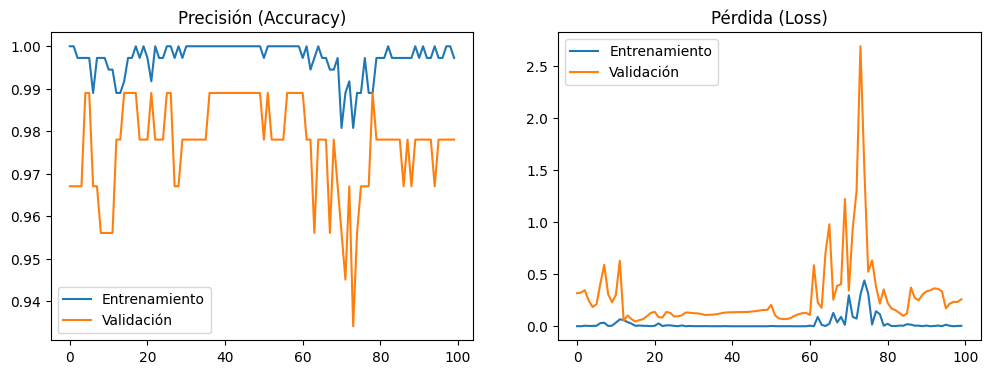

In [ ]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)

# Graficar resultados
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.legend()

plt.show()

Interpretacion


- **Capacidad Adecuada**: Si ambas curvas (Entrenamiento y Validación) suben juntas y se estabilizan en un valor alto, has encontrado una buena arquitectura.

- **Sobreajuste (Overfitting)**: Si la precisión de entrenamiento llega al 100% pero la de validación empieza a bajar (o la pérdida de validación empieza a subir), el modelo tiene "demasiada capacidad" y está memorizando el ruido.

  - Solución: El Keras Tuner probablemente eligió un valor de dropout más alto o menos neuronas para corregirlo.

Al usar este método, se evita el sesgo humano de "probar siempre lo mismo". Por ejemplo, descubrir que para el dataset de Breast Cancer, en lugar de una red muy profunda, el Tuner prefiere una red de 2 capas con muchas neuronas y un Dropout alto para evitar que el modelo se aprenda los datos de memoria (sobreajuste).

## Produccion

In [12]:
import joblib
import tensorflow as tf

# 1. Guardar el modelo de Keras
model.save('best_model_breast_cancer.keras')

# 2. Guardar el escalador (vital para producción)
joblib.dump(scaler, 'scaler_breast_cancer.pkl')

print("¡Archivos exportados con éxito!")

## Para cargar el modelo y el escalador en producción:


# Cargar ambos archivos
loaded_model = tf.keras.models.load_model('best_model_breast_cancer.h5')
loaded_scaler = joblib.load('scaler_breast_cancer.pkl')

def predecir_nuevo_paciente(datos_crudos):
    # Paso 1: Escalar exactamente igual que en el entrenamiento
    datos_listos = loaded_scaler.transform(datos_crudos)
    
    # Paso 2: Predecir
    probabilidad = loaded_model.predict(datos_listos)
    return "Maligno" if probabilidad > 0.5 else "Benigno"

¡Archivos exportados con éxito!


### H5
Guardar un modelo en formato .h5 significa utilizar el estándar HDF5 (Hierarchical Data Format) para almacenar toda la información de tu red neuronal en un único archivo binario eficiente.

Al usar este formato, conservas tres elementos clave:
- **La arquitectura**: La estructura de capas y conexiones del modelo.
- **Los pesos (weights)**: Los valores numéricos que la red aprendió durante el entrenamiento.
- **La configuración del optimizador**: El estado necesario para retomar el entrenamiento exactamente donde se detuvo.

Esto permite que el modelo sea portable, facilitando su carga posterior para realizar predicciones (inferencia) o compartirlo con otros sin necesidad de volver a entrenarlo desde cero. Es el formato que utilizamos habitualmente en Keras cuando configuramos un ModelCheckpoint para salvar la mejor versión de un entrenamiento.

### PKL
Guardar un modelo en formato .pkl se refiere a utilizar la librería Pickle de Python para la serialización de objetos.

Aquí te detallo qué implica este proceso:
- **Serialización**: Consiste en convertir la estructura de datos del modelo (su arquitectura) y sus parámetros aprendidos (pesos y sesgos) en un flujo de bytes que puede almacenarse en un archivo.
- **Persistencia**: Permite que el modelo se guarde en el disco para que no tengas que entrenarlo desde cero cada vez que quieras usarlo.
- **Uso en Producción**: Una vez guardado, puedes cargar el archivo .pkl en un entorno diferente (como un servidor web con Flask) para realizar predicciones o "inferencia" sobre datos nuevos.
- **Herramientas comunes**: Aunque pickle es el estándar de Python, en ciencia de datos se utiliza frecuentemente la librería joblib para archivos .pkl, ya que es más eficiente al manejar modelos que contienen grandes arreglos de datos (como los de Scikit-learn).